# Previsão de alagamentos em São Paulo com Machine Learning
**TCC — Henrique Nascimento Santos · MBA em Data Science e Analytics**  
**Notebook revisado para usar os dados reais e a série `cemaden_estacao_dia.csv`.**

**Objetivo:** aplicar regressão logística, Random Forest, XGBoost e um ensemble de média das probabilidades (*soft voting*) em duas escalas independentes: município e subprefeitura. A comparação entre escalas é descritiva: as prevalências e os alvos diferem.

**Não há resultados pré-preenchidos:** este notebook foi ajustado, mas **não foi executado**. Execute as células no ambiente do seu projeto e examine as auditorias antes de utilizar os resultados no TCC.

**Definição temporal:** ao fim do dia `t`, utilizar somente medições de `t` e de dias anteriores para prever se haverá **registro** de alagamento no dia `t+1`. A classe 0 significa ausência de registro na base do CGE, não inexistência comprovada de alagamento. Dados ERA5 retrospectivos, indicadores urbanos com datas posteriores e previsões arquivadas sem verificação do instante de emissão **não entram nos modelos principais**.

## PARTE I — Fontes, qualidade e consolidação
### 1. Configuração e carregamento
Execute na raiz do repositório ou abra o notebook em `scripts/análises/`. O código localiza a raiz por `data/outputs/datasets/`, sem caminhos fixos do computador. Todos os resultados são gravados apenas em `data/outputs/modelagem_tcc_final/`.

**Dependências:** `pandas`, `numpy`, `matplotlib`, `geopandas`, `scikit-learn`, `xgboost`, `nbformat`, `shapely` e `pyproj`

In [1]:
from pathlib import Path
from IPython.display import display
import hashlib
import inspect
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix, precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
RAIZ_MANUAL = None  # Se necessário, indique Path(r'C:\seu\projeto\Projeto_Previsão_Alagamentos_TCC_2026')

def encontrar_raiz():
    if RAIZ_MANUAL is not None:
        raiz = Path(RAIZ_MANUAL).expanduser().resolve()
        if not (raiz / 'data/outputs/datasets').is_dir():
            raise FileNotFoundError(f'RAIZ_MANUAL não contém data/outputs/datasets/: {raiz}')
        return raiz
    for candidato in (Path.cwd(), *Path.cwd().parents):
        if (candidato / 'data/outputs/datasets').is_dir():
            return candidato
    raise FileNotFoundError('Abra o notebook dentro do projeto ou defina RAIZ_MANUAL.')

ROOT = encontrar_raiz()
DADOS = ROOT / 'data/outputs/datasets'
GEO = ROOT / 'data/outputs/geosampa'
SAIDA = ROOT / 'data/outputs/modelagem_tcc_final'
SAIDA.mkdir(parents=True, exist_ok=True)

ARQUIVOS = {
    'municipal': DADOS / 'dataset_final_integrado.csv',
    'inmet': DADOS / 'consolidated_dataset.csv',
    'estacao_dia': DADOS / 'cemaden_estacao_dia.csv',
    'estacoes': DADOS / 'cemaden_estacoes.csv',
    'cge_regional': GEO / 'cge_subprefeitura_dia.csv',
    'urbanos': GEO / 'indicadores_subprefeituras.csv',
    'limites': GEO / 'subprefeituras_tratadas.gpkg',
    'reanálise': DADOS / 'open_meteo_sp.csv',
    'previsoes_arquivadas': DADOS / 'open_meteo_previous_runs_sp.csv',
}
obrigatorios = list(ARQUIVOS)[:7]
ausentes = {nome: str(ARQUIVOS[nome]) for nome in obrigatorios if not ARQUIVOS[nome].exists()}
if ausentes:
    raise FileNotFoundError(f'Faltam arquivos necessários:\n{json.dumps(ausentes, indent=2, ensure_ascii=False)}')
print('Raiz:', ROOT)
print('Saídas:', SAIDA)

Raiz: c:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026
Saídas: c:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\data\outputs\modelagem_tcc_final


In [2]:
municipal_original = pd.read_csv(ARQUIVOS['municipal'], parse_dates=['date'])
inmet = pd.read_csv(ARQUIVOS['inmet'], parse_dates=['date'])
cge = pd.read_csv(ARQUIVOS['cge_regional'], parse_dates=['date'],
                  dtype={'codigo_subprefeitura': 'string'})
urbanos = pd.read_csv(ARQUIVOS['urbanos'], dtype={'codigo_subprefeitura': 'string'})
estacoes = pd.read_csv(ARQUIVOS['estacoes'], dtype={'cod_estacao': 'string'})
estacao_dia_raw = pd.read_csv(ARQUIVOS['estacao_dia'], dtype={'cod_estacao': 'string'})
limites = gpd.read_file(ARQUIVOS['limites'])
reanálise = (pd.read_csv(ARQUIVOS['reanálise'], parse_dates=['date'])
             if ARQUIVOS['reanálise'].exists() else None)
previsoes_arquivadas = (pd.read_csv(ARQUIVOS['previsoes_arquivadas'], parse_dates=['date'])
                       if ARQUIVOS['previsoes_arquivadas'].exists() else None)

for df, nome, chave in [
    (municipal_original, 'municipal', ['date']), (inmet, 'INMET', ['date']),
    (cge, 'CGE região-dia', ['date', 'codigo_subprefeitura']),
    (urbanos, 'GeoSampa', ['codigo_subprefeitura']),
    (estacoes, 'metadados CEMADEN', ['cod_estacao'])
]:
    if df.duplicated(chave).any():
        raise ValueError(f'{nome}: chave duplicada {chave}; audite antes de prosseguir.')
for df in (cge, urbanos, limites):
    df['codigo_subprefeitura'] = df['codigo_subprefeitura'].astype('string').str.zfill(2)
assert len(urbanos) == len(limites) == 32
assert cge.codigo_subprefeitura.nunique() == 32
assert set(cge.codigo_subprefeitura.unique()) == set(urbanos.codigo_subprefeitura.unique())
assert set(cge.codigo_subprefeitura.unique()) == set(limites.codigo_subprefeitura.unique())

inventario = pd.DataFrame([
    {'fonte': nome, 'arquivo': str(caminho.relative_to(ROOT)),
     'tamanho_MB': round(caminho.stat().st_size / 1e6, 2) if caminho.exists() else np.nan,
     'disponivel': caminho.exists()}
    for nome, caminho in ARQUIVOS.items()
])
inventario.to_csv(SAIDA / 'inventario_fontes.csv', index=False, encoding='utf-8-sig')
display(inventario)

print('CGE:', cge.date.min().date(), 'a', cge.date.max().date(),
      '| subprefeituras:', cge.codigo_subprefeitura.nunique())
print('Vegetação — ano do levantamento:', sorted(urbanos.ano_voo_vegetacao.dropna().unique().tolist()))
print('Drenagem — atualização do cadastro:', urbanos.atualizacao_cadastro_drenagem.dropna().unique().tolist())
print('Coleta CGE confirmada:', cge.coleta_confirmada.notna().sum(),
      'linhas com comprovação; zero de registros não comprova ausência física de alagamento.')

,fonte,arquivo,tamanho_MB,disponivel
0,municipal,data\outputs\datasets\dataset_final_integrado.csv,0.94,True
1,inmet,data\outputs\datasets\consolidated_dataset.csv,1.10,True
2,estacao_dia,data\outputs\datasets\cemaden_estacao_dia.csv,17.86,True
3,estacoes,data\outputs\datasets\cemaden_estacoes.csv,0.01,True
4,cge_regional,data\outputs\geosampa\cge_subprefeitura_dia.csv,3.34,True
5,urbanos,data\outputs\geosampa\indicadores_subprefeitur...,0.01,True
6,limites,data\outputs\geosampa\subprefeituras_tratadas....,1.47,True
7,reanálise,data\outputs\datasets\open_meteo_sp.csv,0.76,True
8,previsoes_arquivadas,data\outputs\datasets\open_meteo_previous_runs...,0.18,True


CGE: 2015-01-01 a 2026-05-31 | subprefeituras: 32
Vegetação — ano do levantamento: [2017]
Drenagem — atualização do cadastro: ['2026-08-19 03:00:00+00:00']
Coleta CGE confirmada: 0 linhas com comprovação; zero de registros não comprova ausência física de alagamento.


### 2. Auditoria do CEMADEN — estação/dia
A nova base **existe** em `data/outputs/datasets/cemaden_estacao_dia.csv` e contém os campos `cod_estacao`, `date`, `precip_total_mm`, `n_leituras`, `lat` e `lon`. Ela será usada diretamente: **não é necessário reconstruir observações individuais a partir da série municipal**.

O tratamento registra (i) linhas sem data; (ii) exclusões documentadas por estação e dia; (iii) valores extremos para revisão; e (iv) provável coleta parcial segundo a frequência de leituras *da mesma estação no mesmo mês*. Um extremo acima de 500 mm/dia fica temporariamente indisponível **até revisão** — isso não significa que ele tenha sido definitivamente classificado como erro. Não preencher lacunas com chuva zero.

**Ponto de controle:** após executar, examine os CSVs de auditoria. Valores extremos e a qualidade da cobertura devem ser revisados antes da versão final do TCC.

In [3]:
estacao_dia = estacao_dia_raw.copy()
estacao_dia['date'] = pd.to_datetime(estacao_dia['date'], errors='coerce').dt.normalize()
estacao_dia['cod_estacao'] = estacao_dia['cod_estacao'].astype('string').str.strip()
for col in ['precip_total_mm', 'n_leituras']:
    estacao_dia[col] = pd.to_numeric(estacao_dia[col], errors='coerce')

sem_data = estacao_dia.loc[estacao_dia.date.isna()].copy()
sem_data.to_csv(SAIDA / 'auditoria_cemaden_sem_data.csv', index=False, encoding='utf-8-sig')
estacao_dia = estacao_dia.dropna(subset=['date']).copy()
if estacao_dia[['cod_estacao', 'precip_total_mm', 'n_leituras']].isna().any().any():
    raise ValueError('Há registros sem código, precipitação ou número de leituras. Revisar entrada.')
if (estacao_dia.precip_total_mm < 0).any() or (estacao_dia.n_leituras <= 0).any():
    raise ValueError('CEMADEN: valores negativos de chuva ou número inválido de leituras.')
if estacao_dia.duplicated(['cod_estacao', 'date']).any():
    estacao_dia.loc[estacao_dia.duplicated(['cod_estacao', 'date'], keep=False)].to_csv(
        SAIDA / 'auditoria_cemaden_duplicatas.csv', index=False, encoding='utf-8-sig')
    raise ValueError('Estação-dia duplicada. Corrija a origem; o notebook não escolhe arbitrariamente uma linha.')
nao_mapeadas = set(estacao_dia.cod_estacao) - set(estacoes.cod_estacao)
if nao_mapeadas:
    raise ValueError(f'Estações sem coordenadas em cemaden_estacoes.csv: {sorted(nao_mapeadas)}')

candidatos_exclusoes = [ROOT / 'scripts/etl/cemaden_exclusoes.csv',
                       DADOS / 'cemaden_exclusoes.csv', ROOT / 'cemaden_exclusoes.csv']
arquivo_exclusoes = next((p for p in candidatos_exclusoes if p.exists()), None)
if arquivo_exclusoes is None:
    raise FileNotFoundError('Não encontrei cemaden_exclusoes.csv. Copie o cadastro de exclusões para scripts/etl/ antes de prosseguir.')
exclusoes = pd.read_csv(arquivo_exclusoes, dtype={'cod_estacao': 'string'}, parse_dates=['date'])
exclusoes['cod_estacao'] = exclusoes.cod_estacao.str.strip()
exclusoes['date'] = exclusoes.date.dt.normalize()
if exclusoes.duplicated(['cod_estacao', 'date']).any():
    raise ValueError('Exclusões duplicadas no cadastro.')
marcacoes = estacao_dia.merge(exclusoes[['cod_estacao','date', 'motivo']],
                              on=['cod_estacao','date'], how='left', indicator=True,
                              validate='one_to_one')
removidos = marcacoes.loc[marcacoes['_merge'].eq('both')].copy()
removidos.to_csv(SAIDA / 'auditoria_cemaden_exclusoes_aplicadas.csv', index=False, encoding='utf-8-sig')
estacao_dia = marcacoes.loc[marcacoes['_merge'].eq('left_only'), estacao_dia.columns].copy()

# Diagnóstico e mascaramento temporário de suspeitas: decisão explícita e auditável.
extremos = estacao_dia.loc[estacao_dia.precip_total_mm > 500].copy()
extremos.to_csv(SAIDA / 'auditoria_cemaden_extremos_revisar.csv', index=False, encoding='utf-8-sig')
estacao_dia['mes'] = estacao_dia.date.dt.to_period('M').astype(str)
estacao_dia['leituras_ref_p90'] = estacao_dia.groupby(['cod_estacao','mes']).n_leituras.transform(
    lambda x: float(x.quantile(.90)))
estacao_dia['suspeita_coleta_parcial'] = (
    (estacao_dia.n_leituras < 18) |
    (estacao_dia.n_leituras < .75 * estacao_dia.leituras_ref_p90)
)
parciais = estacao_dia.loc[estacao_dia.suspeita_coleta_parcial].copy()
parciais.to_csv(SAIDA / 'auditoria_cemaden_parciais_revisar.csv', index=False, encoding='utf-8-sig')
estacao_dia['chuva_valida_mm'] = estacao_dia.precip_total_mm.mask(
    estacao_dia.suspeita_coleta_parcial | (estacao_dia.precip_total_mm > 500))

resumo_qa = pd.DataFrame([{
    'estacao_dias_recebidos': len(estacao_dia_raw), 'linhas_sem_data': len(sem_data),
    'exclusoes_documentadas': len(exclusoes), 'exclusoes_presentes_no_csv': len(removidos),
    'exclusoes_ja_ausentes': len(exclusoes) - len(removidos),
    'extremos_acima_500_para_revisao': len(extremos),
    'estacao_dias_suspeitos_parciais': len(parciais),
    'leituras_diarias_utilizaveis': int(estacao_dia.chuva_valida_mm.notna().sum())
}])
resumo_qa.to_csv(SAIDA / 'auditoria_cemaden_resumo.csv', index=False, encoding='utf-8-sig')
display(resumo_qa)

,estacao_dias_recebidos,linhas_sem_data,exclusoes_documentadas,exclusoes_presentes_no_csv,exclusoes_ja_ausentes,extremos_acima_500_para_revisao,estacao_dias_suspeitos_parciais,leituras_diarias_utilizaveis
0,267469,93,2,0,2,3,126755,140621


### 3. Estimar a chuva para o município e para cada subprefeitura
A interpolação utiliza distâncias em quilômetros no sistema projetado EPSG:31983. Para cada subprefeitura e dia, até **cinco estações válidas** em um raio de **30 km** recebem pesos inversamente proporcionais ao quadrado da distância; exigem-se **duas estações** para calcular a estimativa. Uma região sem suporte suficiente recebe `NaN`, nunca chuva zero. O ponto representativo de cada polígono fica dentro da região.

Para a escala municipal, reconstruiremos uma série de chuva com as **mesmas leituras auditadas**, mas utilizando as estações disponíveis ponderadas pela distância ao centro da cidade (IDW). A série municipal histórica existente permanece preservada para comparação de qualidade.

In [4]:
if limites.crs is None:
    raise ValueError('GPKG sem CRS; não é seguro calcular distâncias.')
limites = limites.to_crs(epsg=31983)
geo_est = gpd.GeoDataFrame(estacoes[['cod_estacao']].copy(),
    geometry=gpd.points_from_xy(estacoes.lon, estacoes.lat),
    crs='EPSG:4326').to_crs(epsg=31983)
regioes_geo = limites[['codigo_subprefeitura', 'nome_subprefeitura', 'geometry']].copy().sort_values('codigo_subprefeitura')
regioes_geo['ponto'] = regioes_geo.geometry.representative_point()

coords_reg = np.c_[regioes_geo.ponto.x.to_numpy(), regioes_geo.ponto.y.to_numpy()]
coords_est = np.c_[geo_est.geometry.x.to_numpy(), geo_est.geometry.y.to_numpy()]
dist_reg = np.linalg.norm(coords_reg[:, None, :] - coords_est[None, :, :], axis=2) / 1000
centro = gpd.GeoSeries(gpd.points_from_xy([-46.6333], [-23.5505]), crs='EPSG:4326').to_crs(epsg=31983)
dist_mun = np.linalg.norm(coords_est - np.array([centro.x.iloc[0], centro.y.iloc[0]]), axis=1) / 1000

calendario = pd.date_range('2015-01-01', '2026-05-31', freq='D', name='date')
matriz = (estacao_dia.pivot(index='date', columns='cod_estacao', values='chuva_valida_mm')
          .reindex(index=calendario, columns=estacoes.cod_estacao))
valores = matriz.to_numpy(dtype=float)

def interpolar_idw(distancias, *, raio_km=None, n_max=None, minimo=2, potencia=2):
    """Precipitação diária por IDW, selecionando apenas estações válidas em cada dia."""
    candidatos = np.argsort(distancias)
    if raio_km is not None:
        candidatos = candidatos[distancias[candidatos] <= raio_km]
    saida = np.full(len(calendario), np.nan)
    quantidade = np.zeros(len(calendario), dtype=int)
    if not len(candidatos):
        return saida, quantidade, 0
    sub = valores[:, candidatos]
    valido = np.isfinite(sub) & (sub >= 0)
    if n_max is None:
        usar = valido
    else:
        usar = valido & (np.cumsum(valido, axis=1) <= n_max)
    quantidade = usar.sum(axis=1)
    pesos = 1 / np.maximum(distancias[candidatos], 0.25) ** potencia
    w = np.where(usar, pesos[None, :], 0.0)
    numer = (np.where(usar, sub, 0.0) * w).sum(axis=1)
    denom = w.sum(axis=1)
    np.divide(numer, denom, out=saida, where=denom > 0)
    saida[quantidade < minimo] = np.nan
    return saida, quantidade, len(candidatos)

mun_chuva, mun_n_est, mun_candidatos = interpolar_idw(dist_mun, n_max=None, minimo=2, potencia=1)
chuva_municipal = pd.DataFrame({'date': calendario, 'cemaden_municipal_qc_mm': mun_chuva,
                                'cemaden_municipal_n_estacoes': mun_n_est})
for janela in (3, 7):
    chuva_municipal[f'cemaden_municipal_acc{janela}d'] = (
        chuva_municipal.cemaden_municipal_qc_mm.rolling(janela, min_periods=janela).sum())

blocos = []
for i, reg in enumerate(regioes_geo.itertuples()):
    chuva, qtd, n_candidatas = interpolar_idw(dist_reg[i], raio_km=30, n_max=5,
                                             minimo=2, potencia=2)
    tmp = pd.DataFrame({'date': calendario, 'codigo_subprefeitura': reg.codigo_subprefeitura,
        'nome_subprefeitura': reg.nome_subprefeitura,
        'cemaden_local_idw_mm': chuva, 'cemaden_local_n_estacoes': qtd,
        'estacoes_no_raio_30km': n_candidatas})
    for janela in (3, 7):
        tmp[f'cemaden_local_acc{janela}d'] = tmp.cemaden_local_idw_mm.rolling(
            janela, min_periods=janela).sum()
    blocos.append(tmp)
chuva_regional = pd.concat(blocos, ignore_index=True)
assert len(chuva_regional) == 32 * len(calendario)
assert not chuva_regional.duplicated(['date','codigo_subprefeitura']).any()

qualidade_regional = (chuva_regional.groupby(['codigo_subprefeitura','nome_subprefeitura'], as_index=False)
    .agg(dias=('date','size'), dias_com_chuva=('cemaden_local_idw_mm','count'),
         mediana_estacoes=('cemaden_local_n_estacoes','median'),
         estacoes_raio=('estacoes_no_raio_30km','first')))
qualidade_regional['cobertura_pct'] = 100 * qualidade_regional.dias_com_chuva / qualidade_regional.dias
qualidade_regional.to_csv(SAIDA/'qualidade_chuva_regional.csv', index=False, encoding='utf-8-sig')
chuva_municipal.to_csv(SAIDA/'cemaden_municipal_reconstruida_qc.csv', index=False, encoding='utf-8-sig')
chuva_regional.to_csv(SAIDA/'cemaden_regional_idw_diario.csv', index=False, encoding='utf-8-sig')
display(qualidade_regional)

,codigo_subprefeitura,nome_subprefeitura,dias,dias_com_chuva,mediana_estacoes,estacoes_raio,cobertura_pct
0,01,PERUS-ANHANGUERA,4169,4077,5.0,57,97.793236
1,02,PIRITUBA-JARAGUA,4169,4088,5.0,71,98.057088
2,03,FREGUESIA-BRASILANDIA,4169,4094,5.0,81,98.201007
3,04,CASA VERDE-LIMAO-CACHOEIRINHA,4169,4094,5.0,88,98.201007
4,05,SANTANA-TUCURUVI,4169,4094,5.0,89,98.201007
5,06,JACANA-TREMEMBE,4169,4084,5.0,79,97.961142
6,07,VILA MARIA-VILA GUILHERME,4169,4096,5.0,90,98.248981
7,08,LAPA,4169,4100,5.0,83,98.344927
8,09,SE,4169,4100,5.0,92,98.344927
9,10,BUTANTA,4169,4099,5.0,80,98.320940


In [5]:
comparacao_chuva = (municipal_original[['date','cemaden_precip_idw_mm']]
    .merge(chuva_municipal[['date','cemaden_municipal_qc_mm']], on='date', validate='one_to_one'))
comparacao_chuva['diferenca_mm'] = (
    comparacao_chuva.cemaden_municipal_qc_mm - comparacao_chuva.cemaden_precip_idw_mm)
comparacao_chuva.to_csv(SAIDA/'auditoria_comparacao_idw_municipal.csv', index=False, encoding='utf-8-sig')
print('Cobertura da chuva municipal após QA:',
      f'{chuva_municipal.cemaden_municipal_qc_mm.notna().mean():.1%}')
print('Diferença absoluta mediana contra a série anterior (mm):',
      round(comparacao_chuva.diferenca_mm.abs().median(), 3))
print('Dias com diferença > 1 mm:', int(comparacao_chuva.diferenca_mm.abs().gt(1).sum()))
print('Revise o CSV de confronto antes de interpretar mudanças frente ao baseline antigo.')

Cobertura da chuva municipal após QA: 98.4%
Diferença absoluta mediana contra a série anterior (mm): 0.22
Dias com diferença > 1 mm: 1119
Revise o CSV de confronto antes de interpretar mudanças frente ao baseline antigo.


### 4. Integrar os alvos e as variáveis meteorológicas

- **Municipal:** uma observação por dia, alvo `has_flooding` deslocado para `D+1`.
- **Regional:** uma observação por subprefeitura/dia, alvo `tem_registro_cge` deslocado para `D+1` **dentro de cada região**.
- **INMET:** série ponderada municipal utilizada como informação regional comum; não é medição local.
- **CEMADEN:** chuva municipal recalculada e chuva local interpolada individualmente.
- **ERA5 e previsões arquivadas:** inventariados, mas **fora do conjunto principal**: não confundir reanálise posterior com previsão disponível em `t` e não misturar coberturas históricas distintas.
- **Indicadores urbanos:** união regional para exploração descritiva; não entram automaticamente nas predições retrospectivas anteriores às datas de seus levantamentos.

In [6]:
variaveis_inmet = ['sp_precip_mm', 'sp_temp_mean', 'sp_umid_mean',
                   'sp_vento_mean', 'sp_pressao_mean']
if any(c not in inmet for c in variaveis_inmet):
    raise KeyError('Faltam variáveis do INMET; verifique consolidated_dataset.csv.')

municipal = (municipal_original[['date','has_flooding']]
    .merge(chuva_municipal, on='date', how='left', validate='one_to_one')
    .merge(inmet[['date', *variaveis_inmet]], on='date', how='left', validate='one_to_one')
    .sort_values('date').reset_index(drop=True))
municipal['data_alvo'] = municipal.date + pd.Timedelta(days=1)
municipal['alvo_amanha'] = municipal.has_flooding.shift(-1)
municipal.loc[~municipal.date.shift(-1).eq(municipal.data_alvo), 'alvo_amanha'] = np.nan
municipal['mes_sin'] = np.sin(2*np.pi*(municipal.data_alvo.dt.month - 1)/12)
municipal['mes_cos'] = np.cos(2*np.pi*(municipal.data_alvo.dt.month - 1)/12)
municipal = municipal.dropna(subset=['alvo_amanha']).copy()
municipal['alvo_amanha'] = municipal.alvo_amanha.astype(int)

# Validar consistência entre o alvo municipal e a presença de registro em alguma região.
validos_cge = cge.loc[cge.dia_presente_base_cge.eq(True)].copy()
conf_cge = (validos_cge.groupby('date', as_index=False).tem_registro_cge.max()
    .rename(columns={'tem_registro_cge':'alguma_regiao'}))
confronto = (municipal[['date','has_flooding']]
    .merge(conf_cge, on='date', how='left', validate='one_to_one'))
confronto.loc[confronto.has_flooding.ne(confronto.alguma_regiao)].to_csv(
    SAIDA/'auditoria_divergencia_alvos.csv', index=False, encoding='utf-8-sig')
if confronto.alguma_regiao.isna().any() or confronto.has_flooding.ne(confronto.alguma_regiao).any():
    raise ValueError('CGE regional e municipal divergem: veja auditoria_divergencia_alvos.csv.')

regional = (cge[['date','codigo_subprefeitura','tem_registro_cge','dia_presente_base_cge']]
    .merge(chuva_regional.drop(columns=['nome_subprefeitura']),
        on=['date','codigo_subprefeitura'], how='left', validate='one_to_one')
    .merge(chuva_municipal, on='date', how='left', validate='many_to_one')
    .merge(inmet[['date',*variaveis_inmet]], on='date', how='left', validate='many_to_one')
    .merge(urbanos[['codigo_subprefeitura','nome_subprefeitura',
        'pct_area_mapeada_vegetacao','densidade_rede_km_por_km2','area_km2']],
        on='codigo_subprefeitura', how='left', validate='many_to_one')
    .sort_values(['codigo_subprefeitura','date']).reset_index(drop=True))
regional['data_alvo'] = regional.date + pd.Timedelta(days=1)
por_regiao = regional.groupby('codigo_subprefeitura', sort=False)
regional['alvo_amanha'] = por_regiao.tem_registro_cge.shift(-1)
proximo_dia = por_regiao.date.shift(-1)
coleta_amanha = por_regiao.dia_presente_base_cge.shift(-1)
regional.loc[~(proximo_dia.eq(regional.data_alvo) & coleta_amanha.eq(True)), 'alvo_amanha'] = np.nan
regional = regional.dropna(subset=['alvo_amanha']).copy()
regional['alvo_amanha'] = regional.alvo_amanha.astype(int)
regional['mes_sin'] = np.sin(2*np.pi*(regional.data_alvo.dt.month - 1)/12)
regional['mes_cos'] = np.cos(2*np.pi*(regional.data_alvo.dt.month - 1)/12)
assert not regional.duplicated(['date','codigo_subprefeitura']).any()
assert (regional.data_alvo - regional.date).eq(pd.Timedelta(days=1)).all()
assert municipal.alvo_amanha.isin([0,1]).all() and regional.alvo_amanha.isin([0,1]).all()
regional.to_csv(SAIDA/'painel_regional_integrado.csv', index=False, encoding='utf-8-sig')
municipal.to_csv(SAIDA/'painel_municipal_integrado.csv', index=False, encoding='utf-8-sig')
print('Municipal:', municipal.shape, '| Regional:', regional.shape)

Municipal: (4168, 15) | Regional: (133376, 26)


## PARTE II — Auditoria e análise exploratória das variáveis
Os algoritmos devem receber apenas atributos defensáveis. **Não usar** `n_registros_cge`, `n_events`, `has_flooding` do próprio dia como preditores automáticos, alvos D+1, erros de previsões arquivadas calculados depois do evento, coordenadas dos eventos ou as séries ERA5 do dia-alvo. A quantidade de estações serve inicialmente para avaliar a qualidade da interpolação, não como variável meteorológica principal.

As variáveis de chuva acumulada incluem **o dia `t`** e são válidas apenas para uma emissão de previsão realizada **após o encerramento do dia `t`**. Se o objetivo mudar para alertas pela manhã, toda a matriz de atributos precisará ser deslocada.

In [7]:
NUM_MUNICIPAL = ['cemaden_municipal_qc_mm', 'cemaden_municipal_acc3d',
                 'cemaden_municipal_acc7d', *variaveis_inmet, 'mes_sin', 'mes_cos']
NUM_REGIONAL = ['cemaden_local_idw_mm', 'cemaden_local_acc3d',
                'cemaden_local_acc7d', 'cemaden_municipal_qc_mm',
                *variaveis_inmet, 'mes_sin', 'mes_cos']
CATEG_MUNICIPAL = []
CATEG_REGIONAL = ['codigo_subprefeitura']
URBANAS_DESCRITIVAS = ['pct_area_mapeada_vegetacao',
                       'densidade_rede_km_por_km2', 'area_km2']
for col in NUM_MUNICIPAL:
    if col not in municipal.columns:
        raise KeyError(f'Variável municipal ausente: {col}')
for col in NUM_REGIONAL + CATEG_REGIONAL + URBANAS_DESCRITIVAS:
    if col not in regional.columns:
        raise KeyError(f'Variável regional ausente: {col}')

# Exigir chuva regional observada em t. As demais lacunas são imputadas pela mediana do treino.
regional_elegivel = regional.loc[regional.cemaden_local_idw_mm.notna()].copy()

meta = {
    'cemaden_municipal_qc_mm': ('CEMADEN estação-dia', 'Chuva observada até t', 'manter'),
    'cemaden_municipal_acc3d': ('CEMADEN estação-dia', 'Chuva observada de t-2 até t', 'manter'),
    'cemaden_municipal_acc7d': ('CEMADEN estação-dia', 'Chuva observada de t-6 até t', 'manter'),
    'cemaden_local_idw_mm': ('CEMADEN estação-dia + limites GeoSampa', 'Chuva regional interpolada em t', 'manter'),
    'cemaden_local_acc3d': ('CEMADEN estação-dia + GeoSampa', 'Chuva regional de t-2 até t', 'manter'),
    'cemaden_local_acc7d': ('CEMADEN estação-dia + GeoSampa', 'Chuva regional de t-6 até t', 'manter'),
    'sp_precip_mm': ('INMET', 'Chuva municipal observada em t', 'manter'),
    'sp_temp_mean': ('INMET', 'Temperatura municipal observada em t', 'manter'),
    'sp_umid_mean': ('INMET', 'Umidade relativa observada em t', 'manter'),
    'sp_vento_mean': ('INMET', 'Vento observado em t', 'manter'),
    'sp_pressao_mean': ('INMET', 'Pressão observada em t', 'manter'),
    'mes_sin': ('Calendário', 'Sazonalidade conhecida antes de t+1', 'manter'),
    'mes_cos': ('Calendário', 'Sazonalidade conhecida antes de t+1', 'manter'),
    'codigo_subprefeitura': ('GeoSampa', 'Identificação regional fixa', 'manter regional'),
    'pct_area_mapeada_vegetacao': ('GeoSampa 2017', 'Levantamento não disponível em todo o histórico', 'descritivo'),
    'densidade_rede_km_por_km2': ('GeoSampa agosto/2026', 'Cadastro posterior ao período-alvo', 'descritivo'),
    'area_km2': ('GeoSampa limites 2026', 'Limites administrativos atuais', 'descritivo'),
}
auditorias = []
for escala, tab, cols in [
    ('municipal', municipal, NUM_MUNICIPAL),
    ('regional', regional_elegivel, NUM_REGIONAL + CATEG_REGIONAL + URBANAS_DESCRITIVAS)
]:
    for var in cols:
        origem, justificativa, decisao = meta[var]
        observado = tab.loc[tab[var].notna(), 'date']
        auditorias.append({'escala':escala,'variavel':var,'fonte':origem,
            'justificativa_temporal':justificativa,'uso':decisao,
            'faltantes_pct':round(100*tab[var].isna().mean(),2),
            'primeira_data':observado.min(),'ultima_data':observado.max()})
auditoria_variaveis = pd.DataFrame(auditorias)
auditoria_variaveis.to_csv(SAIDA/'auditoria_variaveis.csv', index=False, encoding='utf-8-sig')
display(auditoria_variaveis)

coberturas = pd.DataFrame([
    {'escala':'municipal','linhas':len(municipal),'positivos':int(municipal.alvo_amanha.sum()),
     'prevalencia':municipal.alvo_amanha.mean()},
    {'escala':'regional (chuva válida)','linhas':len(regional_elegivel),
     'positivos':int(regional_elegivel.alvo_amanha.sum()),
     'prevalencia':regional_elegivel.alvo_amanha.mean()}
])
display(coberturas)

,escala,variavel,fonte,justificativa_temporal,uso,faltantes_pct,primeira_data,ultima_data
0,municipal,cemaden_municipal_qc_mm,CEMADEN estação-dia,Chuva observada até t,manter,1.61,2015-01-01,2026-05-30
1,municipal,cemaden_municipal_acc3d,CEMADEN estação-dia,Chuva observada de t-2 até t,manter,2.88,2015-01-03,2026-05-30
2,municipal,cemaden_municipal_acc7d,CEMADEN estação-dia,Chuva observada de t-6 até t,manter,4.87,2015-01-07,2026-05-30
3,municipal,sp_precip_mm,INMET,Chuva municipal observada em t,manter,0.00,2015-01-01,2026-05-30
4,municipal,sp_temp_mean,INMET,Temperatura municipal observada em t,manter,0.00,2015-01-01,2026-05-30
5,municipal,sp_umid_mean,INMET,Umidade relativa observada em t,manter,0.00,2015-01-01,2026-05-30
6,municipal,sp_vento_mean,INMET,Vento observado em t,manter,0.00,2015-01-01,2026-05-30
7,municipal,sp_pressao_mean,INMET,Pressão observada em t,manter,0.00,2015-01-01,2026-05-30
8,municipal,mes_sin,Calendário,Sazonalidade conhecida antes de t+1,manter,0.00,2015-01-01,2026-05-30
9,municipal,mes_cos,Calendário,Sazonalidade conhecida antes de t+1,manter,0.00,2015-01-01,2026-05-30


,escala,linhas,positivos,prevalencia
0,municipal,4168,1030,0.247121
1,regional (chuva válida),130617,4434,0.033947


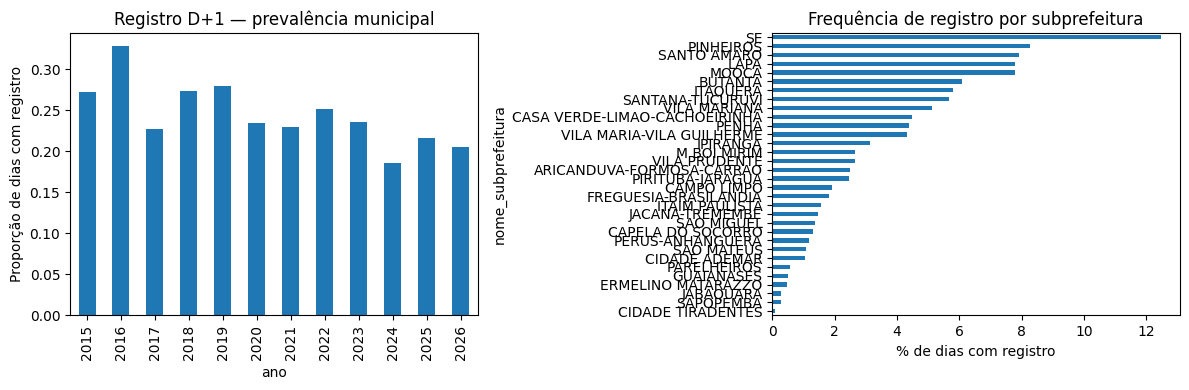

A associação entre frequência de registro, vegetação e drenagem é descritiva, não causal.


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
municipal['ano'] = municipal.data_alvo.dt.year
municipal.groupby('ano').alvo_amanha.mean().plot.bar(ax=axs[0], title='Registro D+1 — prevalência municipal')
axs[0].set_ylabel('Proporção de dias com registro')
perfil = (regional.groupby(['codigo_subprefeitura','nome_subprefeitura'], as_index=False)
          .agg(dias=('date','size'), dias_com_registro=('tem_registro_cge','sum'),
               vegetacao=('pct_area_mapeada_vegetacao','first'),
               densidade_drenagem=('densidade_rede_km_por_km2','first')))
perfil['pct_registros'] = 100*perfil.dias_com_registro/perfil.dias
perfil.sort_values('pct_registros').plot.barh(x='nome_subprefeitura', y='pct_registros',
    ax=axs[1], legend=False, title='Frequência de registro por subprefeitura')
axs[1].set_xlabel('% de dias com registro')
fig.tight_layout()
fig.savefig(SAIDA/'eda_alagamentos_duas_escalas.png', dpi=150, bbox_inches='tight')
plt.show()
perfil.to_csv(SAIDA/'perfil_descritivo_subprefeituras.csv', index=False, encoding='utf-8-sig')
print('A associação entre frequência de registro, vegetação e drenagem é descritiva, não causal.')

## PARTE III — Comparação de modelos na escala municipal
**Modelos:** regressão logística, Random Forest, XGBoost e ensemble por média simples das três probabilidades. As mesmas linhas e atributos são usados nos quatro. Não treinar na validação ou no teste; a validação define o limiar binário (F1) e o teste é reservado para avaliação final.

**Divisão cronológica pelo dia-alvo `t+1`:** treinamento até 2021, validação 2022–2023 e teste 2024–maio/2026. Aplicamos um pequeno embargo na fronteira dos períodos para que rótulos de treino não coincidam com o primeiro dia de informação da etapa seguinte. Faltantes são imputados **pela mediana do treino**, nunca por zero arbitrário.

In [9]:
def separar_temporal(tab):
    tab = tab.sort_values(['data_alvo'] + (['codigo_subprefeitura'] if 'codigo_subprefeitura' in tab else [])).copy()
    tr = tab.loc[tab.data_alvo < '2022-01-01'].copy()
    va = tab.loc[tab.data_alvo.between('2022-01-01', '2023-12-31')].copy()
    te = tab.loc[tab.data_alvo.between('2024-01-01', '2026-05-31')].copy()
    if any(x.empty for x in (tr,va,te)):
        raise ValueError('Faltam observações em algum período; veja qualidade das séries.')
    tr = tr.loc[tr.data_alvo < va.date.min()].copy()
    va = va.loc[va.data_alvo < te.date.min()].copy()
    if not (tr.data_alvo.max() < va.date.min() and va.data_alvo.max() < te.date.min()):
        raise ValueError('Falha no embargo das datas.')
    for nome, parte in [('treino',tr),('validacao',va),('teste',te)]:
        if parte.alvo_amanha.nunique() != 2:
            raise ValueError(f'{nome}: amostra sem as duas classes')
    return tr, va, te

tr_mun, va_mun, te_mun = separar_temporal(municipal)
tr_reg, va_reg, te_reg = separar_temporal(regional_elegivel)
particoes = pd.DataFrame([
    {'escala':escala, 'particao':nome, 'n':len(tab), 'positivos':int(tab.alvo_amanha.sum()),
     'prevalencia':tab.alvo_amanha.mean(),
     'inicio_alvo':tab.data_alvo.min(), 'fim_alvo':tab.data_alvo.max()}
    for escala, tr, va, te in [('municipal',tr_mun,va_mun,te_mun),
                              ('regional',tr_reg,va_reg,te_reg)]
    for nome, tab in [('treino',tr),('validacao',va),('teste',te)]
])
particoes.to_csv(SAIDA/'divisao_temporal.csv', index=False, encoding='utf-8-sig')
display(particoes)

,escala,particao,n,positivos,prevalencia,inicio_alvo,fim_alvo
0,municipal,treino,2555,673,0.263405,2015-01-02,2021-12-30
1,municipal,validacao,729,178,0.244170,2022-01-01,2023-12-30
2,municipal,teste,882,178,0.201814,2024-01-01,2026-05-31
3,regional,treino,79195,2779,0.035091,2015-01-02,2021-12-30
4,regional,validacao,23223,805,0.034664,2022-01-01,2023-12-30
5,regional,teste,28135,847,0.030105,2024-01-01,2026-05-31


In [10]:
def preparar_pipeline(numericas, categoricas, escalar):
    etapas = [('imputar', SimpleImputer(strategy='median'))]
    if escalar:
        etapas.append(('padronizar', StandardScaler()))
    transformadores = [('numericas', Pipeline(etapas), numericas)]
    if categoricas:
        # Compatível com versões recentes e antigas do scikit-learn.
        kw = {'handle_unknown':'ignore'}
        kw['sparse_output' if 'sparse_output' in inspect.signature(OneHotEncoder).parameters
           else 'sparse'] = False
        transformadores.append(('regiao', OneHotEncoder(**kw), categoricas))
    return ColumnTransformer(transformadores, remainder='drop', sparse_threshold=0)

def criar_modelos(numericas, categoricas):
    return {
        'Regressão logística': Pipeline([
            ('prep', preparar_pipeline(numericas, categoricas, True)),
            ('modelo', LogisticRegression(C=1, max_iter=1800, random_state=SEED))]),
        'Random Forest': Pipeline([
            ('prep', preparar_pipeline(numericas, categoricas, False)),
            ('modelo', RandomForestClassifier(n_estimators=200, max_depth=8,
                min_samples_leaf=20, n_jobs=4, random_state=SEED))]),
        'XGBoost': Pipeline([
            ('prep', preparar_pipeline(numericas, categoricas, False)),
            ('modelo', XGBClassifier(n_estimators=220, max_depth=3,
                learning_rate=.05, min_child_weight=15, subsample=.85,
                colsample_bytree=.9, reg_lambda=3, eval_metric='logloss',
                tree_method='hist', n_jobs=4, random_state=SEED))]),
    }

def escolher_limiar(y, p):
    grade = np.unique(np.r_[np.linspace(.01, .99, 99),
                           np.quantile(p, np.linspace(.05,.95,19))])
    resultados = np.array([f1_score(y, p >= t, zero_division=0) for t in grade])
    # Empates resolvidos pelo limiar maior, especificado antes de olhar o teste.
    return float(grade[np.flatnonzero(resultados == resultados.max())[-1]])

def avaliar(y, prob, limiar):
    y = np.asarray(y, dtype=int)
    p = np.asarray(prob, dtype=float)
    pred = (p >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return {'n':len(y),'positivos':int(y.sum()),'prevalencia':float(y.mean()),
            'AP':average_precision_score(y,p), 'ROC_AUC':roc_auc_score(y,p),
            'precisao':precision_score(y,pred,zero_division=0),
            'recall':recall_score(y,pred,zero_division=0),
            'F1':f1_score(y,pred,zero_division=0),'limiar':limiar,
            'VN':int(tn),'FP':int(fp),'FN':int(fn),'VP':int(tp)}

def treinar_quatro(escala, tr, va, te, numericas, categoricas):
    entrada = numericas + categoricas
    if len(entrada) != len(set(entrada)):
        raise ValueError('Atributos duplicados; revise NUM_MUNICIPAL/NUM_REGIONAL.')
    if any(c not in tr.columns for c in entrada):
        raise KeyError('Algumas features não estão disponíveis no painel.')
    if tr[numericas].isna().all().any():
        raise ValueError('Há variáveis inteiramente ausentes no treino; revise seleção.')
    Xtr, Xva, Xte = (parte[entrada] for parte in (tr,va,te))
    ytr, yva, yte = (parte.alvo_amanha.to_numpy() for parte in (tr,va,te))
    modelos = criar_modelos(numericas, categoricas)
    probabilidades_val, probabilidades_teste = {}, {}
    met = []
    for nome, modelo in modelos.items():
        print(f'[{escala}] Treinando {nome}...')
        modelo.fit(Xtr,ytr)
        probabilidades_val[nome] = modelo.predict_proba(Xva)[:,1]
        probabilidades_teste[nome] = modelo.predict_proba(Xte)[:,1]

    # Soft voting sem pesos ajustados e sem retreinamento sobre a validação:
    # os três modelos de base e o ensemble nunca recebem rótulos de validação no .fit().
    probabilidades_val['Ensemble (soft voting)'] = np.mean(
        np.column_stack([probabilidades_val[n] for n in modelos]), axis=1)
    probabilidades_teste['Ensemble (soft voting)'] = np.mean(
        np.column_stack([probabilidades_teste[n] for n in modelos]), axis=1)
    for nome in probabilidades_val:
        limiar = escolher_limiar(yva, probabilidades_val[nome])
        met.append({'escala':escala,'conjunto':'validacao','modelo':nome,
                    **avaliar(yva,probabilidades_val[nome],limiar)})
        met.append({'escala':escala,'conjunto':'teste','modelo':nome,
                    **avaliar(yte,probabilidades_teste[nome],limiar)})
    metricas = pd.DataFrame(met)
    metricas.to_csv(SAIDA/f'metricas_{escala}.csv', index=False, encoding='utf-8-sig')
    previsoes = te[['date','data_alvo','alvo_amanha'] +
        (['codigo_subprefeitura','nome_subprefeitura'] if 'codigo_subprefeitura' in te else [])].copy()
    for nome, p in probabilidades_teste.items():
        previsoes['prob_'+nome.lower().replace(' ','_').replace('(','').replace(')','')] = p
    previsoes.to_csv(SAIDA/f'previsoes_teste_{escala}.csv', index=False, encoding='utf-8-sig')
    return {'modelos':modelos, 'metricas':metricas,
            'val':probabilidades_val,'teste':probabilidades_teste,
            'treino':tr,'validacao':va,'teste_df':te}

In [11]:
resultado_municipal = treinar_quatro('municipal', tr_mun, va_mun, te_mun,
                                      NUM_MUNICIPAL, CATEG_MUNICIPAL)
display(resultado_municipal['metricas'][[
    'modelo','conjunto','prevalencia','AP','ROC_AUC','precisao','recall','F1','limiar']]
    .round(4))

[municipal] Treinando Regressão logística...
[municipal] Treinando Random Forest...
[municipal] Treinando XGBoost...


,modelo,conjunto,prevalencia,AP,ROC_AUC,precisao,recall,F1,limiar
0,Regressão logística,validacao,0.2442,0.5617,0.8213,0.5642,0.6910,0.6212,0.39
1,Regressão logística,teste,0.2018,0.4607,0.7997,0.4255,0.6573,0.5166,0.39
2,Random Forest,validacao,0.2442,0.5722,0.8264,0.5292,0.7135,0.6077,0.38
3,Random Forest,teste,0.2018,0.5032,0.8145,0.4094,0.6854,0.5126,0.38
4,XGBoost,validacao,0.2442,0.5238,0.8145,0.4910,0.7640,0.5978,0.31
5,XGBoost,teste,0.2018,0.4780,0.8100,0.3703,0.7697,0.5000,0.31
6,Ensemble (soft voting),validacao,0.2442,0.5689,0.8289,0.4809,0.8483,0.6138,0.28
7,Ensemble (soft voting),teste,0.2018,0.4889,0.8140,0.3756,0.8483,0.5207,0.28


## PARTE IV — Comparação dos mesmos quatro modelos por subprefeitura

Treinaremos **um único modelo regional** com a variável categórica de identificação da subprefeitura, e não 32 modelos separados. Isso utiliza observações de todas as regiões no treinamento e permite avaliar desempenho de cada uma posteriormente. A chuva regional vem da **base estação-dia recém-disponibilizada** e é interpolada antes da modelagem; não replicamos a precipitação municipal como se fosse local.

Para comparar os algoritmos, todos recebem exatamente o mesmo painel regional elegível e os mesmos atributos. Vegetação e drenagem ficam **descritivas**, porque a drenagem cadastral de 2026 não pode ser tratada como se fosse conhecida em 2015–2021.

In [12]:
resultado_regional = treinar_quatro('regional', tr_reg, va_reg, te_reg,
                                    NUM_REGIONAL, CATEG_REGIONAL)
display(resultado_regional['metricas'][[
    'modelo','conjunto','prevalencia','AP','ROC_AUC','precisao','recall','F1','limiar']]
    .round(4))

[regional] Treinando Regressão logística...
[regional] Treinando Random Forest...
[regional] Treinando XGBoost...


,modelo,conjunto,prevalencia,AP,ROC_AUC,precisao,recall,F1,limiar
0,Regressão logística,validacao,0.0347,0.1643,0.8468,0.1698,0.4969,0.2531,0.11
1,Regressão logística,teste,0.0301,0.1330,0.8241,0.1247,0.4982,0.1994,0.11
2,Random Forest,validacao,0.0347,0.1683,0.8385,0.1645,0.4621,0.2426,0.08
3,Random Forest,teste,0.0301,0.1219,0.8160,0.1245,0.3743,0.1868,0.08
4,XGBoost,validacao,0.0347,0.1691,0.8493,0.1870,0.3975,0.2544,0.11
5,XGBoost,teste,0.0301,0.1239,0.8352,0.1413,0.3530,0.2018,0.11
6,Ensemble (soft voting),validacao,0.0347,0.1745,0.8564,0.1844,0.4509,0.2617,0.10
7,Ensemble (soft voting),teste,0.0301,0.1327,0.8380,0.1359,0.4262,0.2061,0.10


## PARTE V — Resultados, importância das variáveis e discussão
As APs municipal e regional **não são diretamente comparáveis** porque o evento-alvo e sua frequência mudam. O conjunto de teste deve ser consultado apenas depois de fixados atributos, modelos e limiares. Não altere esta análise com base nos resultados finais sem definir um novo conjunto de teste.

,escala,modelo,conjunto,prevalencia,AP,precisao,recall,F1,FP,FN
0,municipal,Regressão logística,validacao,0.2442,0.5617,0.5642,0.6910,0.6212,95,55
1,municipal,Regressão logística,teste,0.2018,0.4607,0.4255,0.6573,0.5166,158,61
2,municipal,Random Forest,validacao,0.2442,0.5722,0.5292,0.7135,0.6077,113,51
3,municipal,Random Forest,teste,0.2018,0.5032,0.4094,0.6854,0.5126,176,56
4,municipal,XGBoost,validacao,0.2442,0.5238,0.4910,0.7640,0.5978,141,42
5,municipal,XGBoost,teste,0.2018,0.4780,0.3703,0.7697,0.5000,233,41
6,municipal,Ensemble (soft voting),validacao,0.2442,0.5689,0.4809,0.8483,0.6138,163,27
7,municipal,Ensemble (soft voting),teste,0.2018,0.4889,0.3756,0.8483,0.5207,251,27
8,regional,Regressão logística,validacao,0.0347,0.1643,0.1698,0.4969,0.2531,1956,405
9,regional,Regressão logística,teste,0.0301,0.1330,0.1247,0.4982,0.1994,2963,425


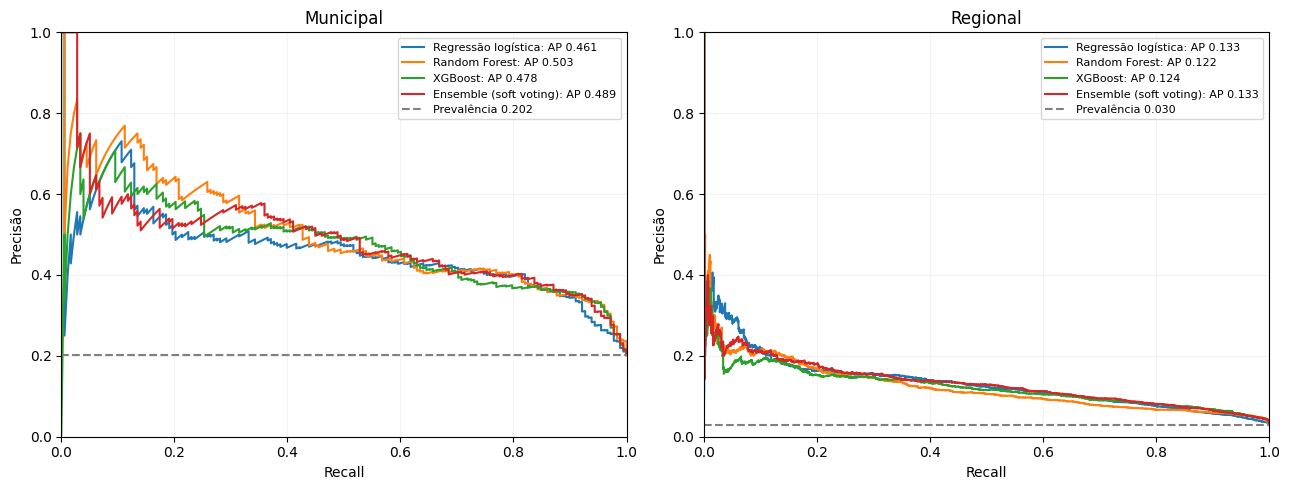

In [13]:
metricas_finais = pd.concat([resultado_municipal['metricas'],resultado_regional['metricas']],
                           ignore_index=True)
metricas_finais.to_csv(SAIDA/'comparacao_quatro_modelos_duas_escalas.csv',
                      index=False, encoding='utf-8-sig')
display(metricas_finais[['escala','modelo','conjunto','prevalencia','AP',
                        'precisao','recall','F1','FP','FN']].round(4))

fig, eixos = plt.subplots(1,2,figsize=(13,5))
for ax, (escala, resultado) in zip(eixos, [('Municipal',resultado_municipal),
                                          ('Regional',resultado_regional)]):
    y = resultado['teste_df'].alvo_amanha.to_numpy()
    for nome, p in resultado['teste'].items():
        pr, rec, _ = precision_recall_curve(y,p)
        ax.plot(rec,pr,label=f'{nome}: AP {average_precision_score(y,p):.3f}')
    ax.axhline(y.mean(),ls='--',color='gray',label=f'Prevalência {y.mean():.3f}')
    ax.set(xlabel='Recall',ylabel='Precisão',title=escala,xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=8)
    ax.grid(alpha=.15)
fig.tight_layout()
fig.savefig(SAIDA/'curvas_pr_4_modelos_2_escalas.png',dpi=150)
plt.show()

In [14]:
# A seleção por AP utiliza exclusivamente a validação, não o teste.
for escala, resultado in [('municipal',resultado_municipal), ('regional',resultado_regional)]:
    val = resultado['metricas'].query("conjunto == 'validacao'")
    selecionado = val.sort_values(['AP','modelo'], ascending=[False,True]).iloc[0]
    nome = selecionado.modelo
    p = resultado['teste'][nome]
    y = resultado['teste_df'].alvo_amanha.to_numpy()
    print(escala, '— modelo selecionado na validação:', nome,
          '| AP de validação:',round(selecionado.AP,4),
          '| AP de teste:',round(average_precision_score(y,p),4))
    if escala == 'regional':
        detalhe = resultado['teste_df'][['codigo_subprefeitura',
                                        'nome_subprefeitura','data_alvo','alvo_amanha']].copy()
        detalhe['probabilidade'] = p
        detalhe['alerta'] = (p >= selecionado.limiar).astype(int)
        por_regiao = detalhe.groupby(['codigo_subprefeitura','nome_subprefeitura'])
        lista = []
        for (codigo,nome_regiao), bloco in por_regiao:
            y_reg = bloco.alvo_amanha.to_numpy()
            p_reg = bloco.probabilidade.to_numpy()
            lista.append({'codigo_subprefeitura':codigo,'nome_subprefeitura':nome_regiao,
                'n':len(bloco),'positivos':int(y_reg.sum()),
                'prevalencia':y_reg.mean(),
                'AP':average_precision_score(y_reg,p_reg) if y_reg.sum() else np.nan,
                'precisao':precision_score(y_reg,bloco.alerta,zero_division=0),
                'recall':recall_score(y_reg,bloco.alerta,zero_division=0)})
        detalhe.to_csv(SAIDA/'previsoes_teste_modelo_regional_selecionado.csv',
                       index=False,encoding='utf-8-sig')
        metricas_sub = pd.DataFrame(lista).sort_values('nome_subprefeitura')
        metricas_sub.to_csv(SAIDA/'metricas_por_subprefeitura.csv',
                           index=False,encoding='utf-8-sig')
        display(metricas_sub.round(3))
        print('AP regional individual indefinida para regiões sem registros positivos no teste.')

municipal — modelo selecionado na validação: Random Forest | AP de validação: 0.5722 | AP de teste: 0.5032
regional — modelo selecionado na validação: Ensemble (soft voting) | AP de validação: 0.1745 | AP de teste: 0.1327


,codigo_subprefeitura,nome_subprefeitura,n,positivos,prevalencia,AP,precisao,recall
25,26,ARICANDUVA-FORMOSA-CARRAO,880,36,0.041,0.100,0.167,0.028
9,10,BUTANTA,880,54,0.061,0.229,0.173,0.556
16,17,CAMPO LIMPO,880,17,0.019,0.054,0.167,0.059
18,19,CAPELA DO SOCORRO,880,9,0.010,0.077,0.000,0.000
3,04,CASA VERDE-LIMAO-CACHOEIRINHA,880,29,0.033,0.119,0.097,0.552
15,16,CIDADE ADEMAR,880,4,0.005,0.009,0.000,0.000
30,31,CIDADE TIRADENTES,880,2,0.002,0.008,0.000,0.000
21,22,ERMELINO MATARAZZO,880,8,0.009,0.019,0.000,0.000
2,03,FREGUESIA-BRASILANDIA,880,12,0.014,0.026,0.000,0.000
27,28,GUAIANASES,880,10,0.011,0.035,0.000,0.000


AP regional individual indefinida para regiões sem registros positivos no teste.


In [15]:
# Importância por permutação na VALIDAÇÃO do modelo individual selecionado
# (o ensemble não possui transformador próprio nem coeficientes diretos).
for escala, resultado, numericas, categ in [
    ('municipal',resultado_municipal,NUM_MUNICIPAL,CATEG_MUNICIPAL),
    ('regional',resultado_regional,NUM_REGIONAL,CATEG_REGIONAL)]:
    val = resultado['metricas'].query("conjunto == 'validacao' and modelo != 'Ensemble (soft voting)'")
    nome = val.sort_values('AP',ascending=False).iloc[0].modelo
    dados = resultado['validacao']
    # Amostragem fixa somente para economizar processamento; as métricas oficiais
    # acima sempre usam o conjunto completo.
    amostra = dados.sample(n=min(10000,len(dados)),random_state=SEED)
    imp = permutation_importance(resultado['modelos'][nome],
        amostra[numericas+categ], amostra.alvo_amanha,
        scoring='average_precision',n_repeats=3,random_state=SEED,n_jobs=2)
    tabela_imp = pd.DataFrame({'variavel':numericas+categ,
        'queda_AP_media':imp.importances_mean,
        'desvio':imp.importances_std}).sort_values('queda_AP_media',ascending=False)
    tabela_imp.to_csv(SAIDA/f'importancia_validacao_{escala}.csv',
                      index=False,encoding='utf-8-sig')
    print(f'{escala}: importância por permutação no modelo {nome}')
    display(tabela_imp.round(4))

municipal: importância por permutação no modelo Random Forest


,variavel,queda_AP_media,desvio
0,cemaden_municipal_qc_mm,0.0708,0.0116
3,sp_precip_mm,0.0517,0.0065
4,sp_temp_mean,0.0320,0.0121
8,mes_sin,0.0197,0.0004
5,sp_umid_mean,0.0183,0.0012
1,cemaden_municipal_acc3d,0.0161,0.0040
9,mes_cos,0.0161,0.0219
6,sp_vento_mean,-0.0022,0.0035
2,cemaden_municipal_acc7d,-0.0046,0.0063
7,sp_pressao_mean,-0.0046,0.0111


regional: importância por permutação no modelo XGBoost


,variavel,queda_AP_media,desvio
11,codigo_subprefeitura,0.0754,0.0025
5,sp_temp_mean,0.0258,0.0027
4,sp_precip_mm,0.0131,0.0066
3,cemaden_municipal_qc_mm,0.0124,0.0032
10,mes_cos,0.0064,0.0024
8,sp_pressao_mean,0.0039,0.0035
7,sp_vento_mean,0.0006,0.0012
0,cemaden_local_idw_mm,0.0002,0.0015
9,mes_sin,0.0001,0.0005
2,cemaden_local_acc7d,0.0000,0.0006


In [16]:
# ============================================================
# CÉLULA EXTRA — Baselines e intervalos de confiança (bootstrap em blocos)
# Colar ao final do notebook, depois da PARTE V.
# Não retreina nada: usa as probabilidades de teste já calculadas.
# ============================================================
BLOCO_DIAS = 14      # tamanho do bloco de dias consecutivos
N_BOOT = 1000        # reamostragens (reduza para 300 se ficar lento)


def escores_de_referencia(escala, tr, te):
    """Modelos de referência. Só usam o treino e informação disponível em t."""
    ref = {}
    # 1) Prevalência do treino: classificador sem informação (AP esperada = prevalência do teste)
    ref['Prevalência (sem informação)'] = np.full(len(te), tr.alvo_amanha.mean())
    # 2) Persistência: houve registro hoje (t) -> prevê registro amanhã (t+1)
    col_hoje = 'has_flooding' if escala == 'municipal' else 'tem_registro_cge'
    ref['Persistência'] = te[col_hoje].astype(float).to_numpy()
    # 3) Climatologia: frequência histórica do treino por mês do dia-alvo
    #    (municipal: só mês; regional: subprefeitura + mês)
    chaves = ['mes_alvo'] if escala == 'municipal' else ['codigo_subprefeitura', 'mes_alvo']
    trm = tr.assign(mes_alvo=tr.data_alvo.dt.month)
    tem = te.assign(mes_alvo=te.data_alvo.dt.month)
    freq = trm.groupby(chaves).alvo_amanha.mean().rename('freq').reset_index()
    clim = tem[chaves].merge(freq, on=chaves, how='left')['freq']
    ref['Climatologia (mês)' if escala == 'municipal' else 'Climatologia (subpref. + mês)'] = (
        clim.fillna(tr.alvo_amanha.mean()).to_numpy())
    return ref


def preparar_blocos(datas):
    dias = np.sort(np.unique(datas))
    dia_idx = np.searchsorted(dias, datas)
    linhas_por_dia = [np.flatnonzero(dia_idx == k) for k in range(len(dias))]
    return len(dias), linhas_por_dia


def amostra_bootstrap(n_dias, linhas_por_dia, rng, bloco):
    n_blocos = int(np.ceil(n_dias / bloco))
    inicios = rng.integers(0, max(n_dias - bloco, 0) + 1, n_blocos)
    dias_sel = (inicios[:, None] + np.arange(bloco)).ravel()[:n_dias]
    return np.concatenate([linhas_por_dia[k] for k in dias_sel])


def analisar_escala(escala, resultado, tr, pares, seed=SEED):
    te = resultado['teste_df']
    y = te.alvo_amanha.to_numpy()
    escores = {**resultado['teste'], **escores_de_referencia(escala, tr, te)}
    n_dias, linhas_por_dia = preparar_blocos(te.data_alvo.to_numpy())
    rng = np.random.default_rng(seed)

    aps = {nome: [] for nome in escores}
    difs = {par: [] for par in pares}
    for _ in range(N_BOOT):
        idx = amostra_bootstrap(n_dias, linhas_por_dia, rng, BLOCO_DIAS)
        yb = y[idx]
        if yb.sum() == 0:
            continue
        ap_b = {nome: average_precision_score(yb, s[idx]) for nome, s in escores.items()}
        for nome, v in ap_b.items():
            aps[nome].append(v)
        for (a, b) in pares:
            difs[(a, b)].append(ap_b[a] - ap_b[b])

    prev = y.mean()
    linhas = []
    for nome, s in escores.items():
        ap = average_precision_score(y, s)
        lo, hi = np.percentile(aps[nome], [2.5, 97.5])
        linhas.append({'escala': escala, 'modelo': nome, 'AP': ap, 'IC95_inf': lo, 'IC95_sup': hi,
                       'ROC_AUC': roc_auc_score(y, s), 'lift_sobre_prevalencia': ap / prev})
    tab = pd.DataFrame(linhas)

    linhas_d = []
    for (a, b) in pares:
        d = average_precision_score(y, escores[a]) - average_precision_score(y, escores[b])
        lo, hi = np.percentile(difs[(a, b)], [2.5, 97.5])
        linhas_d.append({'escala': escala, 'comparacao': f'{a} − {b}', 'dif_AP': d,
                         'IC95_inf': lo, 'IC95_sup': hi,
                         'IC_inclui_zero': bool(lo <= 0 <= hi)})
    return tab, pd.DataFrame(linhas_d), prev


PARES_MUN = [('Random Forest', 'Regressão logística'), ('Random Forest', 'XGBoost'),
             ('Random Forest', 'Persistência'), ('Random Forest', 'Climatologia (mês)')]
PARES_REG = [('Ensemble (soft voting)', 'Regressão logística'),
             ('Ensemble (soft voting)', 'Climatologia (subpref. + mês)'),
             ('Ensemble (soft voting)', 'Persistência')]

tab_mun, dif_mun, prev_mun = analisar_escala('municipal', resultado_municipal, tr_mun, PARES_MUN)
tab_reg, dif_reg, prev_reg = analisar_escala('regional', resultado_regional, tr_reg, PARES_REG)

tabela_ic = pd.concat([tab_mun, tab_reg], ignore_index=True)
tabela_dif = pd.concat([dif_mun, dif_reg], ignore_index=True)
tabela_ic.to_csv(SAIDA / 'baselines_e_ic_bootstrap.csv', index=False, encoding='utf-8-sig')
tabela_dif.to_csv(SAIDA / 'diferencas_ap_bootstrap.csv', index=False, encoding='utf-8-sig')
print(f'Prevalência no teste — municipal: {prev_mun:.3f} | regional: {prev_reg:.3f}')
display(tabela_ic.round(4))
display(tabela_dif.round(4))

Prevalência no teste — municipal: 0.202 | regional: 0.030


,escala,modelo,AP,IC95_inf,IC95_sup,ROC_AUC,lift_sobre_prevalencia
0,municipal,Regressão logística,0.4607,0.3575,0.5718,0.7997,2.2829
1,municipal,Random Forest,0.5032,0.3951,0.6033,0.8145,2.4933
2,municipal,XGBoost,0.4780,0.3864,0.5631,0.8100,2.3688
3,municipal,Ensemble (soft voting),0.4889,0.3848,0.5879,0.8140,2.4226
4,municipal,Prevalência (sem informação),0.2018,0.1553,0.2608,0.5000,1.0000
5,municipal,Persistência,0.3600,0.2706,0.4496,0.6938,1.7838
6,municipal,Climatologia (mês),0.4286,0.3328,0.5331,0.7757,2.1236
7,regional,Regressão logística,0.1330,0.0877,0.1841,0.8241,4.4171
8,regional,Random Forest,0.1219,0.0876,0.1599,0.8160,4.0496
9,regional,XGBoost,0.1239,0.0910,0.1583,0.8352,4.1168


,escala,comparacao,dif_AP,IC95_inf,IC95_sup,IC_inclui_zero
0,municipal,Random Forest − Regressão logística,0.0424,-0.0157,0.1031,True
1,municipal,Random Forest − XGBoost,0.0251,-0.0121,0.0562,True
2,municipal,Random Forest − Persistência,0.1432,0.0874,0.2095,False
3,municipal,Random Forest − Climatologia (mês),0.0746,-0.0165,0.1476,True
4,regional,Ensemble (soft voting) − Regressão logística,-0.0003,-0.0158,0.0120,True
5,regional,Ensemble (soft voting) − Climatologia (subpref...,0.0174,-0.0028,0.0387,True
6,regional,Ensemble (soft voting) − Persistência,0.0858,0.0617,0.1119,False


### Discussão e limites a registrar no TCC

1. **Desbalanceamento:** relatar a prevalência de cada escala ao lado da AP; acurácia isolada seria enganosa.
2. **Registro ≠ ocorrência física confirmada:** zero no CGE significa apenas que não há registro no arquivo. Cobertura de coleta individual não está comprovada.
3. **Observações até `t`:** o estudo é uma retrospectiva de D+1 emitida após o encerramento de `t`; disponibilidade efetiva em tempo real, particularmente de produtos reanalisados, precisaria ser verificada antes de uso operacional.
4. **CEMADEN:** revisar `auditoria_cemaden_sem_data.csv`, `auditoria_cemaden_extremos_revisar.csv`, `auditoria_cemaden_parciais_revisar.csv` e o confronto do IDW municipal. A regra sobre frequência é uma **heurística de triagem**, não certificação de cobertura horária.
5. **GeoSampa:** vegetação (levantamento 2017), drenagem (cadastro atualizado em 2026) e limites de 2026 descrevem *snapshots* territoriais; não são prova da configuração física existente desde 2015. É possível utilizá-los em mapas e tabelas descritivas, mas excluí-los do experimento principal impede o vazamento retrospectivo.
6. **Ensemble:** a média simples combina pontuações dos três modelos; **sem calibração**, esses números não devem ser interpretados como probabilidades operacionalmente calibradas. A melhoria não é garantida; resultados devem ser reportados tal como encontrados.
7. **Limites da comparação:** municipal e regional têm objetivos e prevalências diferentes; apresentar os quatro modelos e o ensemble em tabelas separadas. Não modificar os experimentos depois de examinar o teste.
8. **Open-Meteo Previous Runs:** se for incorporado futuramente, documentar instante real da emissão das previsões horárias, cobertura a partir de 2024 e validação em novo recorte temporal. Não utilizar colunas `*_error_*` como preditores (dependem da observação posterior).

**Saídas finais:** métricas por escala, curvas Precision-Recall, previsões no teste, importância de variáveis na validação, qualidade da precipitação regional, inventário e auditorias, todos em `data/outputs/modelagem_tcc_final/`.